In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import networkx as nx

import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option('display.max_columns', None)

In [2]:
# load uvm_courses.csv as courses_df
courses_df = pd.read_csv('uvm_courses_standardized_11_20_25.csv')

# load enrollment_data_combined.csv
enrollment_df = pd.read_csv('enrollment_data_combined.csv')

/var/folders/nb/clbb898j3mncw_pfsj58zfv80000gn/T/ipykernel_36693/1668001819.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  courses_df = pd.read_csv('uvm_courses_standardized_11_20_25.csv')
/var/folders/nb/clbb898j3mncw_pfsj58zfv80000gn/T/ipykernel_36693/1668001819.py:5: DtypeWarning: Columns (0,1,5,7,9,19,21,22,23,24,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  enrollment_df = pd.read_csv('enrollment_data_combined.csv')


In [3]:
courses_df.head()

,year,cat_type,ipeds_id,department,catalog_prefix,course_number,title,instructors,cross_listed_with,is_subcourse,is_truncated,is_continued_from_previous,full_entry,first_instructor,num_instructors,prefix_cleaned,department_cleaned,prefix_cleaned_from_dept,prefix_cleaned_from_prefix,department_cleaned_from_prefix,department_cleaned_from_dept
0,1965,gr,231174,economics,ECON,276,C.P.A. PROBLEMS,['Mr. Nyquist'],[],False,False,False,276 C.P.A. PROBLEMS Review of questions and pr...,Mr. Nyquist,1,EC,economics,EC,EC,economics,economics
1,1965,gr,231174,economics,ECON,286,ECONOMIC ANALYSIS,['Mr. Wass'],[],False,False,False,"286 ECONOMIC ANALYSIS Analysis of demand, supp...",Mr. Wass,1,EC,economics,EC,EC,economics,economics
2,1965,gr,231174,economics,ECON,288,QUALITY CONTROL,['Mr. Saunders'],[],False,False,False,288 QUALITY CONTROL The application of statist...,Mr. Saunders,1,EC,economics,EC,EC,economics,economics
3,1965,gr,231174,economics,ECON,290,THE SOVIET ECONOMY,['Mr. Dellin'],[],False,False,False,290 THE SOVIET ECONOMY An analysis of the econ...,Mr. Dellin,1,EC,economics,EC,EC,economics,economics
4,1965,gr,231174,economics,ECON,291,ECONOMIC PATTERNS AND POLICIES OF EASTERN EUROPE,['Mr. Dellin'],[],False,False,False,291 ECONOMIC PATTERNS AND POLICIES OF EASTERN ...,Mr. Dellin,1,EC,economics,EC,EC,economics,economics


# Initial Data Cleaning - Enrollment df

In [4]:
# filter enrollment_df to only include rows that we're fairly confident are just courses
course_dept_counts = enrollment_df.groupby('Title')['Department'].nunique().reset_index()
course_dept_counts = course_dept_counts.sort_values(by='Department', ascending=False).reset_index(drop=True)
course_dept_counts

KeyError: 'Column not found: Department'

In [ ]:
# What proportion of courses are offered in just one department? 89%. Two departments? 8.6%
one_dept_courses = course_dept_counts[course_dept_counts['Department'] == 1]
two_dept_courses = course_dept_counts[course_dept_counts['Department'] == 2]

100*(one_dept_courses.shape[0] / course_dept_counts.shape[0]), 100*(two_dept_courses.shape[0] / course_dept_counts.shape[0])

(89.35413860200569, 8.569076485556055)

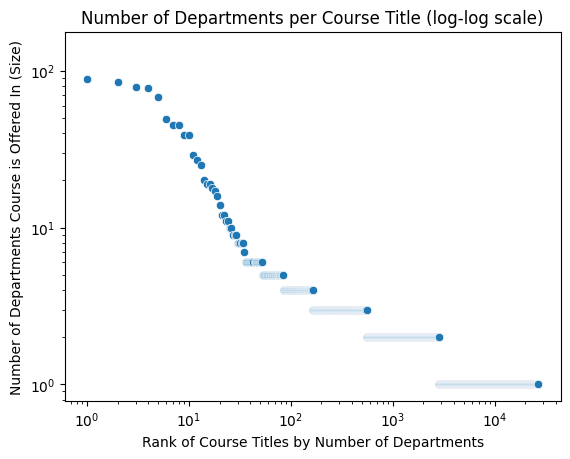

In [19]:
# Plot size - Rank plot of number of departments per course title
import numpy as np
from scipy import stats

# Plot size - Rank plot of number of departments per course title
sns.scatterplot(data=course_dept_counts, x=course_dept_counts.index, y='Department')

# Calculate linear regression on log-log scale
# x = np.log10(course_dept_counts.index)
# y = np.log10(course_dept_counts['Department'])
# slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# # Plot regression line
# x_line = np.array([course_dept_counts.index.min(), course_dept_counts.index.max()])
# y_line = 10**(slope * np.log10(x_line) + intercept)
# plt.plot(x_line, y_line, 'r-', label=f'y = {10**intercept:.2f}x^{slope:.2f}\nR² = {r_value**2:.3f}')

plt.yscale('log')
plt.xscale('log')
plt.title('Number of Departments per Course Title (log-log scale)')
plt.xlabel('Rank of Course Titles by Number of Departments')
plt.ylabel('Number of Departments Course is Offered In (Size)')
# plt.legend()
plt.show()

In [20]:
enrollment_df

,Subj,#,Title,Comp Numb,Sec,Ptrm,Lec Lab,Attr,Camp Code,Coll Code,Max Enrollment,Current Enrollment,True Max,Start Time,End Time,Days,Credits,Bldg,Room,GP Ind,Instructor,NetId,Email,Fees,XListings,Year,Semester,Dept,Instructor First,Instructor Last,Department
0,ABIO,6020,ABIO Graduate Seminar,13772,A,1,SEM,NaN,M,CALS,20,10,NaN,13:10,14:00,F,1,TERRIL,308,Y,"Machado de Sant'Anna, Felipe",fsantann,Felipe.Santanna@uvm.edu,NaN,,2025,Spring,NaN,NaN,NaN,ABIO
1,ABIO,6391,Master's Thesis Research,13766,A,1,TD,NaN,M,CALS,20,1,NaN,TBA,NaN,,1 to 18,NaN,NaN,N,"Kraft, Jana",jkraft1,Jana.Kraft@uvm.edu,NaN,,2025,Spring,NaN,NaN,NaN,ABIO
2,ABIO,6391,Master's Thesis Research,13767,B,1,TD,NaN,M,CALS,20,2,NaN,TBA,NaN,,1 to 18,NaN,NaN,N,"Barlow, John William",jbarlow,John.Barlow@uvm.edu,NaN,,2025,Spring,NaN,NaN,NaN,ABIO
3,ABIO,6391,Master's Thesis Research,13768,C,1,TD,NaN,M,CALS,20,2,NaN,TBA,NaN,,1 to 18,NaN,NaN,N,"Smith, Julie M",jmsmith,Julie.M.Smith@uvm.edu,NaN,,2025,Spring,NaN,NaN,NaN,ABIO
4,ABIO,6391,Master's Thesis Research,13769,D,1,TD,NaN,M,CALS,20,0,NaN,TBA,NaN,,1 to 18,NaN,NaN,N,"Zhao, Feng-Qi",fzhao,fzhao@uvm.edu,NaN,,2025,Spring,NaN,NaN,NaN,ABIO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261826,NaN,195,Psychology of Women,92397,E,NaN,L,NaN,C,NaN,20,0,NaN,16:30,19:00,W,3,DEWEY,238,NaN,Downey Sar,NaN,NaN,NaN,NaN,1995,Fall,WST,NaN,NaN,WST
261827,NaN,195,Women & Depression,92416,F,NaN,L,NaN,C,NaN,1,19,NaN,TBA,NaN,,3,NaN,NaN,NaN,Gleeson,NaN,NaN,NaN,NaN,1995,Fall,WST,NaN,NaN,WST
261828,NaN,195,Women's Spirituality,92417,G,NaN,L,NaN,C,NaN,20,18,NaN,16:10,19:00,W,3,L/L-B,B101,NaN,Cleary,NaN,NaN,NaN,NaN,1995,Fall,WST,NaN,NaN,WST
261829,NaN,195,Gender & Law,92492,H,NaN,L,NaN,C,NaN,20,13,NaN,17:40,20:30,R,3,69 UHT,100,NaN,Taormina,NaN,NaN,NaN,NaN,1995,Fall,WST,NaN,NaN,WST


In [ ]:
# filter the enrollment dataframe to just proposed courses - only listed in 1 department or X-listed if available

filtered_enrollment_df = enrollment_df[enrollment_df['Title'].isin(course_dept_counts[course_dept_counts['Department'] == 1]['Title'])]

In [8]:
# Merge dataframes using fuzzymatching on titles and years
merged_year_title_df = pd.merge(enrollment_df, uvm_courses_df, left_on=['Year', 'Title'], right_on=['start_yr', 'Title'], how='outer', indicator=True)

In [9]:
# The merged dataset is 11x larger than the original UVM courses dataset (duplicate courses ... ?) and about 9.5x larger than the enrollment dataset
merged_year_title_df.shape[0] / uvm_courses_df.shape[0], merged_year_title_df.shape[0] / enrollment_df.shape[0]

(11.247019622695957, 9.526790181452922)

# Network Based Research on cc Data

In [5]:
courses_df.head()

,year,cat_type,ipeds_id,department,catalog_prefix,course_number,title,instructors,cross_listed_with,is_subcourse,is_truncated,is_continued_from_previous,full_entry,first_instructor,num_instructors,prefix_cleaned,department_cleaned,prefix_cleaned_from_dept,prefix_cleaned_from_prefix,department_cleaned_from_prefix,department_cleaned_from_dept
0,1965,gr,231174,economics,ECON,276,C.P.A. PROBLEMS,['Mr. Nyquist'],[],False,False,False,276 C.P.A. PROBLEMS Review of questions and pr...,Mr. Nyquist,1,EC,economics,EC,EC,economics,economics
1,1965,gr,231174,economics,ECON,286,ECONOMIC ANALYSIS,['Mr. Wass'],[],False,False,False,"286 ECONOMIC ANALYSIS Analysis of demand, supp...",Mr. Wass,1,EC,economics,EC,EC,economics,economics
2,1965,gr,231174,economics,ECON,288,QUALITY CONTROL,['Mr. Saunders'],[],False,False,False,288 QUALITY CONTROL The application of statist...,Mr. Saunders,1,EC,economics,EC,EC,economics,economics
3,1965,gr,231174,economics,ECON,290,THE SOVIET ECONOMY,['Mr. Dellin'],[],False,False,False,290 THE SOVIET ECONOMY An analysis of the econ...,Mr. Dellin,1,EC,economics,EC,EC,economics,economics
4,1965,gr,231174,economics,ECON,291,ECONOMIC PATTERNS AND POLICIES OF EASTERN EUROPE,['Mr. Dellin'],[],False,False,False,291 ECONOMIC PATTERNS AND POLICIES OF EASTERN ...,Mr. Dellin,1,EC,economics,EC,EC,economics,economics


In [43]:
# clean course title - lowercase
courses_df['title_lower'] = courses_df['title'].str.lower().str.strip()

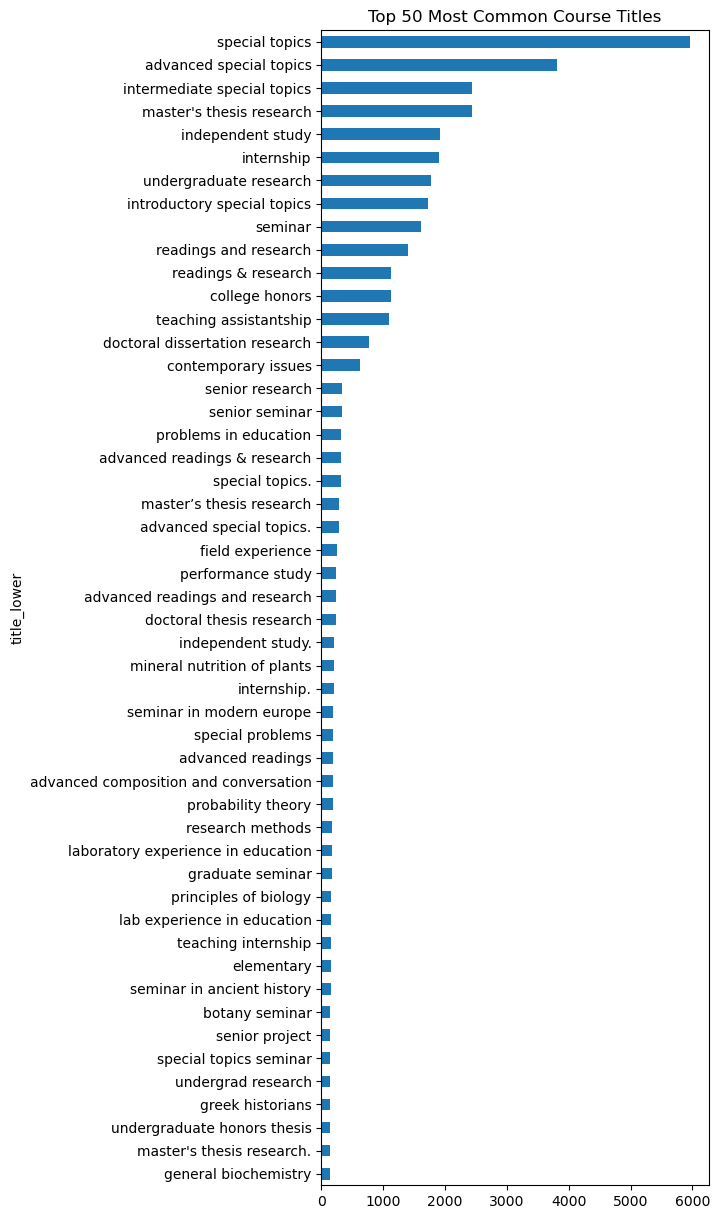

In [44]:
plt.title('Top 50 Most Common Course Titles')
courses_df['title_lower'].value_counts().head(50).sort_values(ascending=True).plot(kind='barh', figsize=(5,15))
plt.show()

# Idea:

1. Can we cluster courses based on their full entry descriptions?
- some courses are lectures, some are labs


In [17]:
courses_df[courses_df['first_instructor'].str.contains('Staff', na=False)]

,year,cat_type,ipeds_id,department,catalog_prefix,course_number,title,instructors,cross_listed_with,is_subcourse,is_truncated,is_continued_from_previous,full_entry,first_instructor,num_instructors,prefix_cleaned,department_cleaned,prefix_cleaned_from_dept,prefix_cleaned_from_prefix,department_cleaned_from_prefix,department_cleaned_from_dept
9,1965,gr,231174,economics,ECON,297,SEMINAR,['Staff'],[],False,False,False,"297, 298 SEMINAR Review of recent books and pe...",Staff,1,EC,economics,EC,EC,economics,economics
10,1965,gr,231174,economics,ECON,298,SEMINAR,['Staff'],[],False,False,False,"297, 298 SEMINAR Review of recent books and pe...",Staff,1,EC,economics,EC,EC,economics,economics
20,1965,gr,231174,latin,NaN,381,SEMINAR,['Staff'],[],False,False,False,"381, 382, 383, 384 SEMINAR Intensive study at ...",Staff,1,LAT,latin,LAT,NaN,NaN,latin
21,1965,gr,231174,latin,NaN,382,SEMINAR,['Staff'],[],False,False,False,"381, 382, 383, 384 SEMINAR Intensive study at ...",Staff,1,LAT,latin,LAT,NaN,NaN,latin
22,1965,gr,231174,latin,NaN,383,SEMINAR,['Staff'],[],False,False,False,"381, 382, 383, 384 SEMINAR Intensive study at ...",Staff,1,LAT,latin,LAT,NaN,NaN,latin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221747,1965,gr,231174,french,NaN,391 THROUGH 399,MASTER'S THESIS RESEARCH,['Staff'],[],False,False,False,391 THROUGH 399 MASTER'S THESIS RESEARCH Inves...,Staff,1,FREN,french,FREN,NaN,NaN,french
221902,1964,gr,231174,chemistry,CHEM,221,ADVANCED THEORETICAL CHEMISTRY,['Staff'],[],False,False,False,221 ADVANCED THEORETICAL CHEMISTRY Selected to...,Staff,1,CHEM,chemistry,CHEM,CHEM,chemistry,chemistry
221904,1964,gr,231174,chemistry,CHEM,231,SPECIAL TOPICS IN ORGANIC CHEMISTRY,['Staff'],[],False,False,False,"231, 232 SPECIAL TOPICS IN ORGANIC CHEMISTRY A...",Staff,1,CHEM,chemistry,CHEM,CHEM,chemistry,chemistry
221905,1964,gr,231174,chemistry,CHEM,232,SPECIAL TOPICS IN ORGANIC CHEMISTRY,['Staff'],[],False,False,False,"231, 232 SPECIAL TOPICS IN ORGANIC CHEMISTRY A...",Staff,1,CHEM,chemistry,CHEM,CHEM,chemistry,chemistry


In [15]:
courses_df['first_instructor'].value_counts().head(20)

first_instructor
Staff        7341
The staff     562
Davison       328
Berkowitz     321
Ambrose       299
Allen         239
Hall          229
Mieder        221
McKenna       221
Danigelis     219
Bryan         215
Gordon        204
Mahoney       181
Hutton        180
Barnum        176
Gade          174
Hannah        170
The Staff     166
Clark         164
Donnelly      164
Name: count, dtype: int64

In [6]:
courses_df['department_cleaned'].value_counts().head(10)

department_cleaned
education                 8889
history                   8283
english                   7132
mathematics               6232
electrical engineering    5674
chemistry                 5439
mechanical engineering    5406
political science         5294
sociology                 5285
music                     5152
Name: count, dtype: int64

education: -0.5000
history: -0.5000
english: -0.5000
mathematics: -0.5000
electrical engineering: -0.5000
chemistry: -0.5000
mechanical engineering: -0.5000
political science: -0.5000
sociology: -0.5000
music: -0.5000


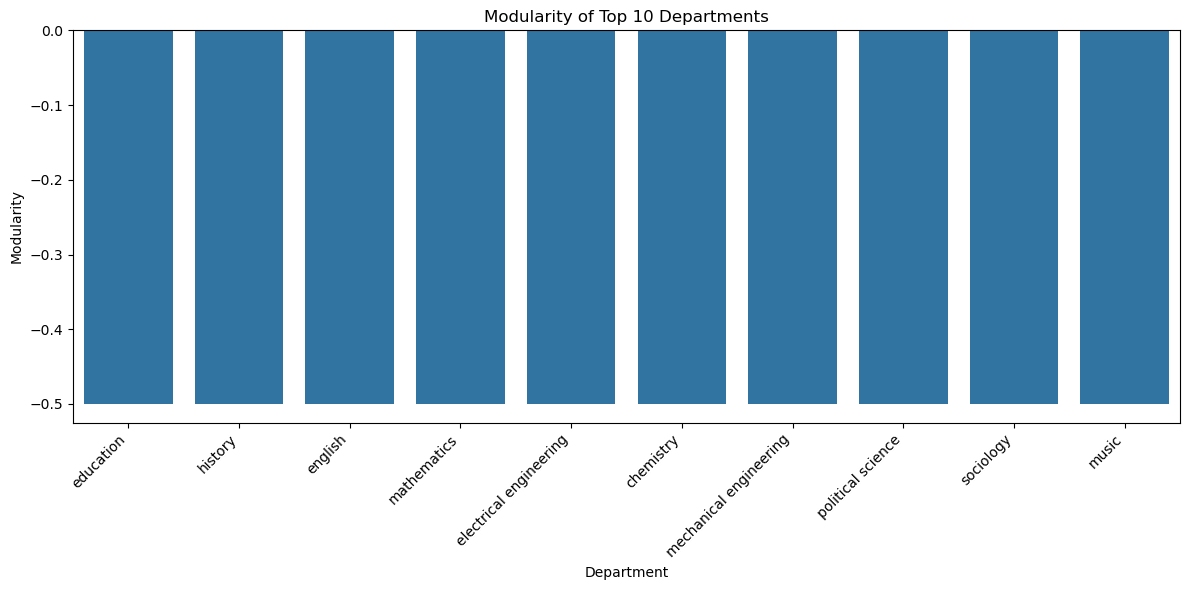

In [9]:
def compute_department_modularity(department_name, graph):
    """
    Filter network to a given department and compute modularity.
    
    Parameters:
    -----------
    department_name : str
        Name of the department to filter
    graph : networkx.Graph
        The bipartite graph with instructors and courses
        
    Returns:
    --------
    float
        Modularity score for the department, or None if no courses found
    """
    # Filter courses for the given department
    dept_courses = [node for node, attr in graph.nodes(data=True) 
                    if attr.get('node_type') == 'course' 
                    and attr.get('department') == department_name]
    
    if len(dept_courses) == 0:
        return None
    
    # Get instructors connected to these courses
    connected_instructors = [node for node in graph.nodes() 
                            if graph.nodes[node].get('node_type') == 'instructor' 
                            and any(graph.has_edge(node, course) for course in dept_courses)]
    
    # Create subgraph
    subgraph = graph.subgraph(dept_courses + connected_instructors)
    
    # Check if subgraph has edges
    if subgraph.number_of_edges() == 0:
        return None
    
    # Create partition: instructors vs courses
    instructors = set(n for n in subgraph.nodes() if subgraph.nodes[n].get('node_type') == 'instructor')
    courses = set(n for n in subgraph.nodes() if subgraph.nodes[n].get('node_type') == 'course')
    
    # Compute modularity
    modularity = nx.algorithms.community.modularity(subgraph, [instructors, courses])
    
    return modularity

# Get top 10 most frequent departments
top_10_depts = courses_df['department_cleaned'].value_counts().head(10)

# Compute modularity for each department
modularity_results = {}
for dept in top_10_depts.index:
    mod = compute_department_modularity(dept, G)
    if mod is not None:
        modularity_results[dept] = mod
        print(f"{dept}: {mod:.4f}")

# Create a dataframe for plotting
modularity_df = pd.DataFrame(list(modularity_results.items()), 
                              columns=['Department', 'Modularity'])

# Plot the results
plt.figure(figsize=(12, 6))
sns.barplot(data=modularity_df, x='Department', y='Modularity')
plt.xticks(rotation=45, ha='right')
plt.title('Modularity of Top 10 Departments')
plt.xlabel('Department')
plt.ylabel('Modularity')
plt.tight_layout()
plt.show()

In [11]:
# Create a bipartite network with instructors and courses
G = nx.Graph()

# Add nodes for courses with their metadata
for idx, row in courses_df.iterrows():
    course_id = f"COURSE_{row['title']}"
    G.add_node(course_id, 
               node_type='course',
               title=row['title'],
               description=row.get('full_entry', ''),
               department=row.get('department_cleaned', ''))

# Add nodes for instructors and edges connecting them to courses
for idx, row in courses_df.iterrows():
    if pd.notna(row.get('first_instructor', '')):
        instructor = row['first_instructor']
        course_id = f"COURSE_{row['title']}"
        
        # Add instructor node if not already present
        if instructor not in G:
            G.add_node(instructor, node_type='instructor')
        
        # Add edge between instructor and course
        G.add_edge(instructor, course_id)

print(f"Network created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"Instructors: {sum(1 for n, d in G.nodes(data=True) if d.get('node_type') == 'instructor')}")
print(f"Courses: {sum(1 for n, d in G.nodes(data=True) if d.get('node_type') == 'course')}")

Network created with 27694 nodes and 19297 edges
Instructors: 3199
Courses: 24495



Yearly Network Metrics:
 year  n_instructors  n_courses  n_edges      density  n_components  avg_degree
 1938              2          6        6 2.142857e-01             2    1.500000
 1939              8         45       15 1.088534e-02            38    0.566038
 1940             24         83       47 8.287780e-03            60    0.878505
 1941             14         41       23 1.548822e-02            32    0.836364
 1942             49        142       87 4.794709e-03           104    0.910995
 1944             74        336      170 2.027551e-03           241    0.829268
 1945             76        323      212 2.669992e-03           187    1.062657
 1946            108        432      328 2.253831e-03           212    1.214815
 1948            101        311      223 2.633879e-03           189    1.082524
 1949            141        526      382 1.719861e-03           285    1.145427
 1950            109        317      250 2.761668e-03           176    1.173709
 1951          

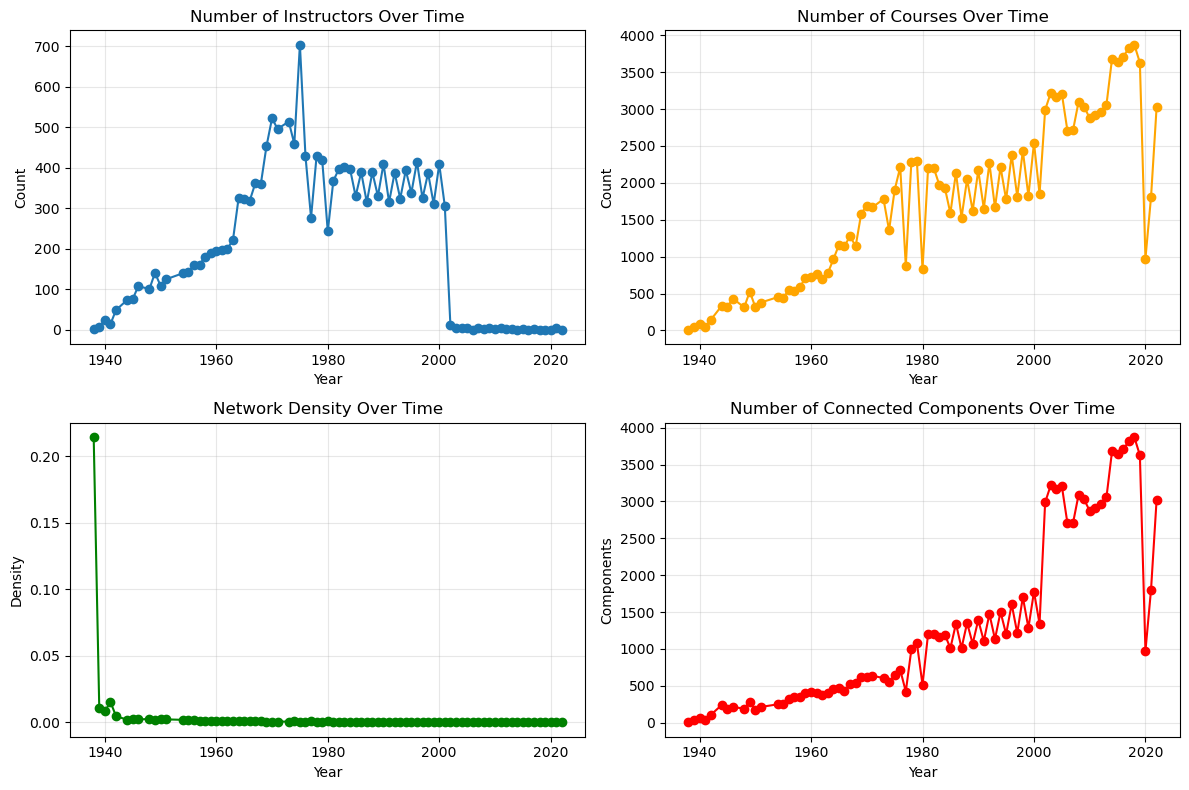

In [12]:
# ============================================================================
# Partition by year and compute network-level metrics
# ============================================================================

courses_df['year'] = pd.to_numeric(courses_df['year'], errors='coerce')

# Group by year and create yearly networks
yearly_networks = {}
yearly_metrics = []

for year in sorted(courses_df['year'].dropna().unique()):
    # Filter data for this year
    year_data = courses_df[courses_df['year'] == year]
    
    # Create yearly bipartite network
    G_year = nx.Graph()
    
    # Add course nodes
    for idx, row in year_data.iterrows():
        course_id = f"COURSE_{row['title']}"
        G_year.add_node(course_id, 
                       node_type='course',
                       title=row['title'],
                       department=row.get('department_cleaned', ''))
    
    # Add instructor nodes and edges
    for idx, row in year_data.iterrows():
        if pd.notna(row.get('first_instructor', '')):
            instructor = row['first_instructor']
            course_id = f"COURSE_{row['title']}"
            
            if instructor not in G_year:
                G_year.add_node(instructor, node_type='instructor')
            
            G_year.add_edge(instructor, course_id)
    
    yearly_networks[year] = G_year
    
    # Compute metrics
    n_instructors = sum(1 for n, d in G_year.nodes(data=True) if d.get('node_type') == 'instructor')
    n_courses = sum(1 for n, d in G_year.nodes(data=True) if d.get('node_type') == 'course')
    n_edges = G_year.number_of_edges()
    density = nx.density(G_year)
    n_components = nx.number_connected_components(G_year)
    avg_degree = sum(dict(G_year.degree()).values()) / G_year.number_of_nodes() if G_year.number_of_nodes() > 0 else 0
    
    yearly_metrics.append({
        'year': int(year),
        'n_instructors': n_instructors,
        'n_courses': n_courses,
        'n_edges': n_edges,
        'density': density,
        'n_components': n_components,
        'avg_degree': avg_degree
    })

# Convert to DataFrame for easy viewing
metrics_df = pd.DataFrame(yearly_metrics)
print("\n" + "="*80)
print("Yearly Network Metrics:")
print("="*80)
print(metrics_df.to_string(index=False))

# Optionally, compute growth rates
print("\n" + "="*80)
print("Year-over-Year Growth Rates:")
print("="*80)
metrics_df['instructor_growth'] = metrics_df['n_instructors'].pct_change() * 100
metrics_df['course_growth'] = metrics_df['n_courses'].pct_change() * 100
print(metrics_df[['year', 'instructor_growth', 'course_growth']].to_string(index=False))

# Visualize trends
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(metrics_df['year'], metrics_df['n_instructors'], marker='o')
axes[0, 0].set_title('Number of Instructors Over Time')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(metrics_df['year'], metrics_df['n_courses'], marker='o', color='orange')
axes[0, 1].set_title('Number of Courses Over Time')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(metrics_df['year'], metrics_df['density'], marker='o', color='green')
axes[1, 0].set_title('Network Density Over Time')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Density')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(metrics_df['year'], metrics_df['n_components'], marker='o', color='red')
axes[1, 1].set_title('Number of Connected Components Over Time')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Components')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()